# Metabolomics overview plot

Date created: 12/19/2024

Notebook author: Yang Chen

Data analysis by: Britta De Pessemier

This notebook plots the following:
- Metabolomics overview plots showing number of total metabolites, with and without suspects library, and classified annotations

In [83]:
# Import Python packages
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from matplotlib_venn import venn3


In [84]:
# Read in table of all spectra and output number of total metabolites
info_feature_complete = pd.read_csv('../Data/metabolomics/Run3_10252024/info_feature_complete.csv')
total_num_metabolites = info_feature_complete.shape[0]
print(f'Total number of consensus MS2 spectra metabolites from GNPS2: ' + str(total_num_metabolites))

Total number of consensus MS2 spectra metabolites from GNPS2: 7683


In [85]:
# Read in GNPS2 metabolites table obtained WITHOUT suspects library
gnps_without_suspects = pd.read_csv('../Data/metabolomics/Run3_10252024/merged_results_with_gnps_withoutsuspects.tsv', sep='\t')
num_gnps_without_suspects = gnps_without_suspects.shape[0]
print(f'Number of GNPS2 outputed metabolites WITHOUT suspects library: ' + str(num_gnps_without_suspects))

Number of GNPS2 outputed metabolites WITHOUT suspects library: 432


In [86]:
# Read in GNPS2 metabolites table obtained WITH suspects library
gnps_with_suspects = pd.read_csv('../Data/metabolomics/Run3_10252024/merged_results_with_gnps.tsv', sep='\t')
num_gnps_with_suspects = gnps_with_suspects.shape[0]
print(f'Number of GNPS2 outputed metabolites WITH suspects library: ' + str(num_gnps_with_suspects))

Number of GNPS2 outputed metabolites WITH suspects library: 1027


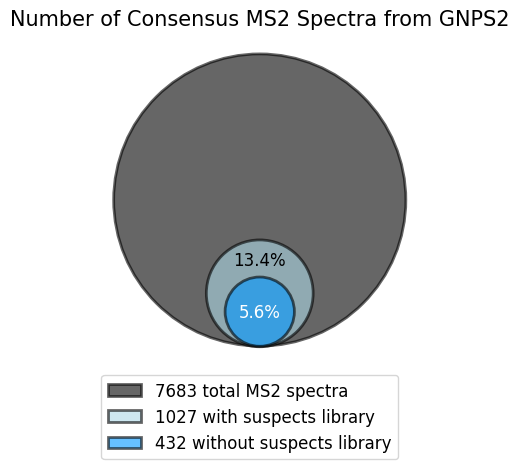

In [ ]:
# Define circle sizes
size1 = total_num_metabolites  # Size of Circle 1
size2 = num_gnps_with_suspects   # Size of Circle 2
size3 = num_gnps_without_suspects   # Size of Circle 3

# Calculate the radii based on the square root of the sizes (scaled for visualization)
scaling_factor = 0.005  # Adjust this value for appropriate circle size in the plot

radius1 = np.sqrt(size1) * scaling_factor  # Radius for Circle 1
radius2 = np.sqrt(size2) * scaling_factor  # Radius for Circle 2
radius3 = np.sqrt(size3) * scaling_factor  # Radius for Circle 3

# Calculate the percentage for each circle relative to the total size
total_size = size1
percent1 = (size2 / size1) * 100
percent2 = (size3 / size1) * 100

# Create a figure
fig, ax = plt.subplots()

# Choose aesthetically pleasing colors (pastel-like colors)
circle1 = plt.Circle((0.5, 0.5), radius1, facecolor='#000000', alpha=0.6, edgecolor='black', linewidth=2, label=f'{size1} total MS2 spectra')
circle2 = plt.Circle((0.5, 0.22), radius2, facecolor='#ADD8E6', alpha=0.6, edgecolor='black', linewidth=2, label=f'{size2} with suspects library')
circle3 = plt.Circle((0.5, 0.165), radius3, facecolor='#0096FF', alpha=0.6, edgecolor='black', linewidth=2, label=f'{size3} without suspects library')

# Add the circles to the plot
ax.add_patch(circle1)
ax.add_patch(circle2)
ax.add_patch(circle3)

# Add percentage text inside the circles
# ax.text(0.5, 0.5, f'{percent1:.1f}%', ha='center', va='center', fontsize=12, color='white')
ax.text(0.5, 0.32, f'{percent1:.1f}%', ha='center', va='center', fontsize=12, color='black')
ax.text(0.5, 0.165, f'{percent2:.1f}%', ha='center', va='center', fontsize=12, color='white')

# Set limits to ensure all circles are fully visible
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Set aspect ratio to be equal to ensure circles are circular
ax.set_aspect('equal')

# Remove all borders
for spine in ax.spines.values():
    spine.set_visible(False)

# Remove ticks and labels
ax.set_xticks([])
ax.set_yticks([])

# Add legend for the circles with their respective sizes and place it outside the plot
ax.legend(loc='upper left', bbox_to_anchor=(0, 0), fontsize=12)

# Add title with better font style and size
plt.title("Number of Consensus MS2 Spectra from GNPS2", loc='center', fontsize=15)

# Adjust layout to make room for the legend
plt.tight_layout()

# Save figure
plt.savefig('../Figures/metabolomics_Figures/overview/ms2_venn_diagram.png', dpi=600)
# Show the plot
plt.show()
